In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("/Users/nguyentien/Documents/DHV/vietnam_ecommerce_2023.csv")
df.head()
df.info()
print(df.describe())
print("\nShape of the dataframe:", df.shape)
print(df.isnull().sum())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         8000 non-null   object 
 1   order_date       8000 non-null   object 
 2   month            8000 non-null   int64  
 3   quarter          8000 non-null   object 
 4   day_of_week      8000 non-null   object 
 5   customer_id      8000 non-null   object 
 6   gender           8000 non-null   object 
 7   age_group        8000 non-null   object 
 8   city             8000 non-null   object 
 9   region           8000 non-null   object 
 10  channel          8000 non-null   object 
 11  payment_method   8000 non-null   object 
 12  category         8000 non-null   object 
 13  quantity         8000 non-null   int64  
 14  unit_price       8000 non-null   int64  
 15  gross_value      8000 non-null   int64  
 16  discount_pct     8000 non-null   float64
 17  discount_amoun

Biểu đồ net_value mỗi tháng

<Axes: xlabel='month'>

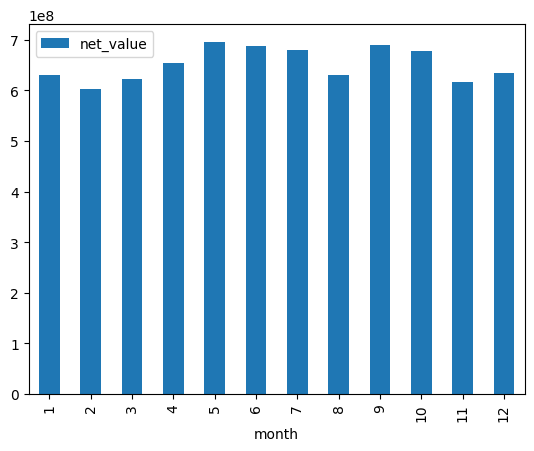

In [18]:
df.pivot_table(values='net_value', index='month', aggfunc='sum').plot(kind='bar')

<Axes: xlabel='month'>

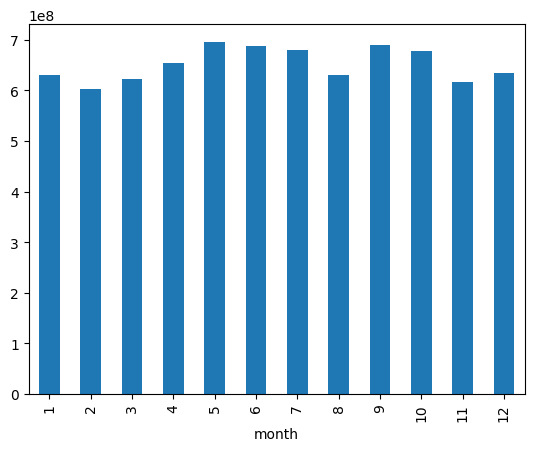

In [4]:
df.groupby('month')['net_value'].sum().plot(kind='bar')

Biểu đồ net_value của từng loại

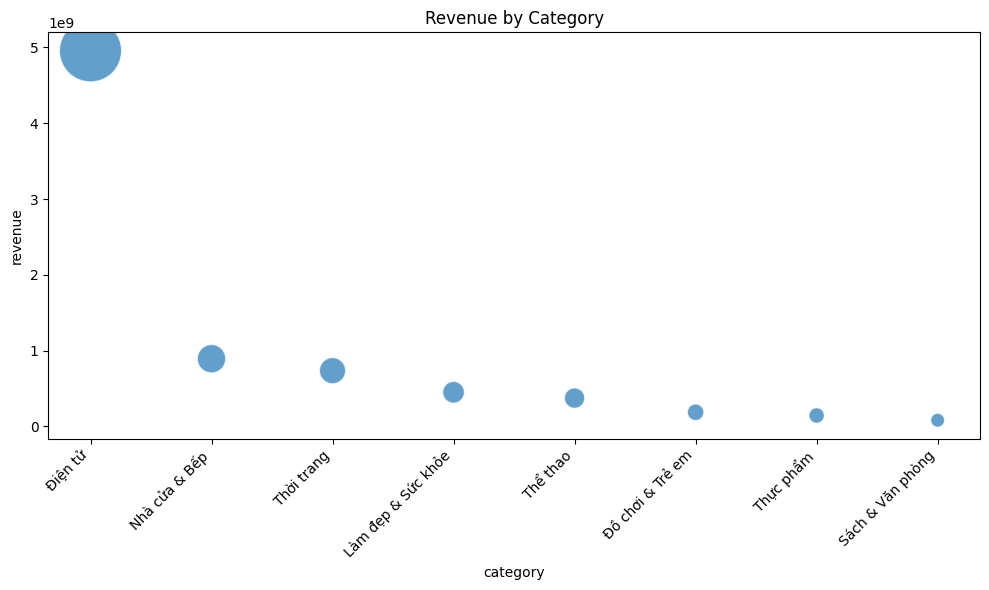

In [19]:
##Scatter plot chart for revenue by category
category_revenue = df.groupby('category', as_index=False).agg(revenue=('net_value', 'sum')).sort_values('revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=category_revenue,
    x='category',
    y='revenue',
    size='revenue',
    sizes=(100, 2000),
    legend=False,
    alpha=0.7
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('category')
plt.ylabel('revenue')
plt.title('Revenue by Category')
plt.tight_layout()

## S03 - Giảm giá sâu hơn 30% làm tăng hoàn hàng và ăn mòn lợi nhuận

Câu trả lời được tính trực tiếp từ `discount_pct`, `returned`, `profit`. Code bên dưới phân nhóm chiết khấu, so sánh tỉ lệ hoàn hàng và lợi nhuận trung bình.


,discount_tier,orders,return_rate,avg_profit,avg_net_value,return_rate_pct,avg_profit_million,avg_net_value_million
0,<10%,6356,0.089679,169586.418817,1.004278e+06,8.967904,0.169586,1.004278
1,10-20%,1355,0.100369,146559.111439,9.177439e+05,10.036900,0.146559,0.917744
2,20-30%,200,0.105000,120571.630000,7.074012e+05,10.500000,0.120572,0.707401
3,>=30%,89,0.247191,66497.000000,6.191271e+05,24.719101,0.066497,0.619127


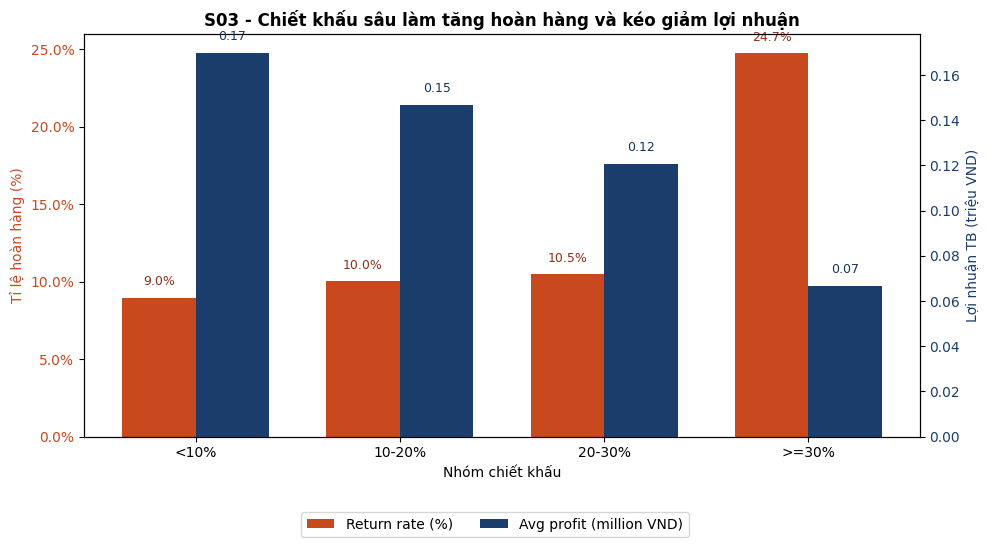

Kết luận S03: Nhóm giảm giá >=30% có tỉ lệ hoàn hàng 24.7%, cao hơn rõ rệt so với nhóm <10% (9.0%). Lợi nhuận trung bình chỉ còn 66,497 VND/đơn, thấp hơn 60.8% so với nhóm chiết khấu thấp.


In [20]:
# S03: Discount tier vs return rate & average profit
import matplotlib.ticker as mtick

s03 = df.copy()
s03['discount_tier'] = np.select(
    [
        s03['discount_pct'] < 0.10,
        s03['discount_pct'] < 0.20,
        s03['discount_pct'] < 0.30,
        s03['discount_pct'] >= 0.30,
    ],
    ['<10%', '10-20%', '20-30%', '>=30%'],
    default='Khac'
)

tier_order = ['<10%', '10-20%', '20-30%', '>=30%']
s03_stats = (
    s03.groupby('discount_tier')
       .agg(
           orders=('order_id', 'count'),
           return_rate=('returned', 'mean'),
           avg_profit=('profit', 'mean'),
           avg_net_value=('net_value', 'mean')
       )
       .reindex(tier_order)
       .reset_index()
)

display(
    s03_stats.assign(
        return_rate_pct=s03_stats['return_rate'] * 100,
        avg_profit_million=s03_stats['avg_profit'] / 1_000_000,
        avg_net_value_million=s03_stats['avg_net_value'] / 1_000_000,
    )
)

fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(s03_stats))
bar1 = ax1.bar(x - 0.18, s03_stats['return_rate'] * 100, width=0.36, color='#C8491E', label='Return rate (%)')
ax1.set_ylabel('Tỉ lệ hoàn hàng (%)', color='#C8491E')
ax1.tick_params(axis='y', labelcolor='#C8491E')
ax1.set_xticks(x)
ax1.set_xticklabels(s03_stats['discount_tier'])
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax2 = ax1.twinx()
bar2 = ax2.bar(x + 0.18, s03_stats['avg_profit'] / 1_000_000, width=0.36, color='#1A3D6B', label='Avg profit (million VND)')
ax2.set_ylabel('Lợi nhuận TB (triệu VND)', color='#1A3D6B')
ax2.tick_params(axis='y', labelcolor='#1A3D6B')

for i, row in s03_stats.iterrows():
    ax1.text(i - 0.18, row['return_rate'] * 100 + 0.8, f"{row['return_rate']*100:.1f}%", ha='center', fontsize=9, color='#8F2F18')
    ax2.text(i + 0.18, row['avg_profit'] / 1_000_000 + 0.006, f"{row['avg_profit']/1_000_000:.2f}", ha='center', fontsize=9, color='#16365C')

ax1.set_title('S03 - Chiết khấu sâu làm tăng hoàn hàng và kéo giảm lợi nhuận', fontweight='bold')
ax1.set_xlabel('Nhóm chiết khấu')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)
plt.tight_layout()
plt.show()

base_profit = s03_stats.loc[s03_stats['discount_tier'] == '<10%', 'avg_profit'].iloc[0]
high_discount = s03_stats.loc[s03_stats['discount_tier'] == '>=30%'].iloc[0]
profit_drop = (base_profit - high_discount['avg_profit']) / base_profit

print(
    f"Kết luận S03: Nhóm giảm giá >=30% có tỉ lệ hoàn hàng {high_discount['return_rate']:.1%}, "
    f"cao hơn rõ rệt so với nhóm <10% ({s03_stats.loc[0, 'return_rate']:.1%}). "
    f"Lợi nhuận trung bình chỉ còn {high_discount['avg_profit']:,.0f} VND/đơn, "
    f"thấp hơn {profit_drop:.1%} so với nhóm chiết khấu thấp."
)


## S04 - Miền Trung giao hàng chậm hơn nhưng đơn giá cao nhất

Code nhóm theo `region` để so sánh thời gian giao hàng trung bình và giá trị đơn hàng trung bình.


,orders,avg_order,avg_delivery,revenue,avg_order_million,revenue_billion
region,,,,,,
Miền Nam,4186,9.682524e+05,2.152652,4053104624,0.968252,4.053105
Miền Bắc,2594,9.688186e+05,2.205860,2513115453,0.968819,2.513115
Miền Trung,1220,1.030409e+06,3.490984,1257099438,1.030409,1.257099


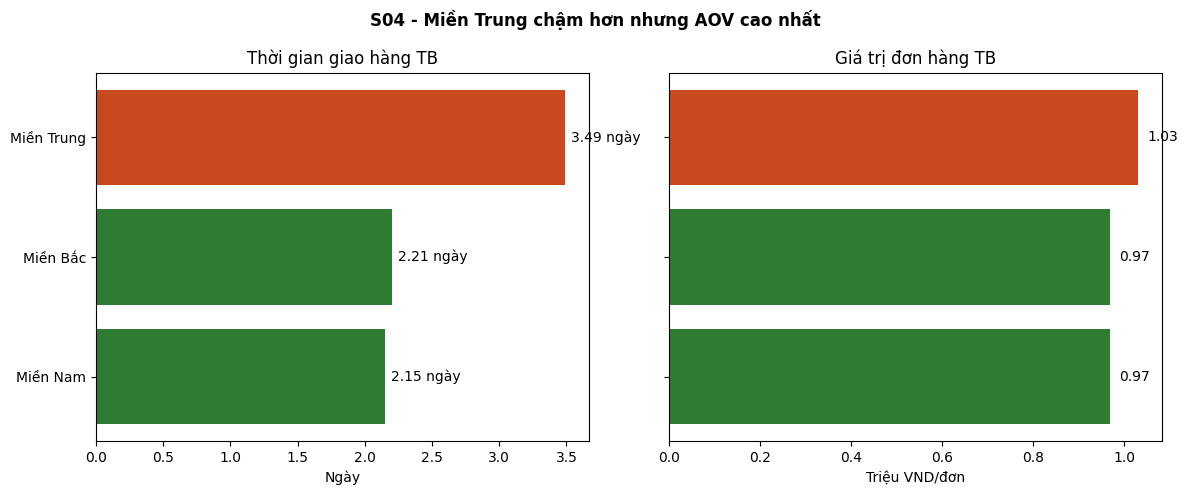

Kết luận S04: Miền Trung giao trung bình 3.49 ngày, khoảng 1.6 lần Miền Nam (2.15 ngày). Tuy vậy, AOV Miền Trung đạt 1,030,409 VND/đơn, cao nhất trong 3 miền.


In [21]:
# S04: Region delivery speed vs average order value
s04_stats = (
    df.groupby('region')
      .agg(
          orders=('order_id', 'count'),
          avg_order=('net_value', 'mean'),
          avg_delivery=('delivery_days', 'mean'),
          revenue=('net_value', 'sum')
      )
      .sort_values('avg_delivery', ascending=True)
)

display(
    s04_stats.assign(
        avg_order_million=s04_stats['avg_order'] / 1_000_000,
        revenue_billion=s04_stats['revenue'] / 1_000_000_000,
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = ['#2E7D32' if region != 'Miền Trung' else '#C8491E' for region in s04_stats.index]

axes[0].barh(s04_stats.index, s04_stats['avg_delivery'], color=colors)
axes[0].set_title('Thời gian giao hàng TB')
axes[0].set_xlabel('Ngày')
for y, value in enumerate(s04_stats['avg_delivery']):
    axes[0].text(value + 0.04, y, f'{value:.2f} ngày', va='center')

axes[1].barh(s04_stats.index, s04_stats['avg_order'] / 1_000_000, color=colors)
axes[1].set_title('Giá trị đơn hàng TB')
axes[1].set_xlabel('Triệu VND/đơn')
for y, value in enumerate(s04_stats['avg_order'] / 1_000_000):
    axes[1].text(value + 0.02, y, f'{value:.2f}', va='center')

fig.suptitle('S04 - Miền Trung chậm hơn nhưng AOV cao nhất', fontweight='bold')
plt.tight_layout()
plt.show()

central = s04_stats.loc['Miền Trung']
south = s04_stats.loc['Miền Nam']
print(
    f"Kết luận S04: Miền Trung giao trung bình {central['avg_delivery']:.2f} ngày, "
    f"khoảng {central['avg_delivery']/south['avg_delivery']:.1f} lần Miền Nam ({south['avg_delivery']:.2f} ngày). "
    f"Tuy vậy, AOV Miền Trung đạt {central['avg_order']:,.0f} VND/đơn, cao nhất trong 3 miền."
)


## S05 - Thời trang có tỉ lệ hoàn hàng cao nhất toàn sàn

Code nhóm theo `category`, tính `returned.mean()` và highlight ngành hàng rủi ro nhất.


,orders,revenue,return_rate,profit,margin,return_rate_pct,revenue_billion,margin_pct
category,,,,,,,,
Thời trang,1727,735744033,0.189346,193598401,0.263133,18.934569,0.735744,26.313282
Đồ chơi & Trẻ em,579,186977488,0.107081,51560882,0.275760,10.708117,0.186977,27.575984
Nhà cửa & Bếp,1139,893382937,0.084284,262819426,0.294185,8.428446,0.893383,29.418451
Thể thao,633,374132820,0.071090,117759092,0.314752,7.109005,0.374133,31.475210
Làm đẹp & Sức khỏe,1261,450728999,0.070579,171638646,0.380802,7.057891,0.450729,38.080231
Điện tử,1425,4955754493,0.062456,479412156,0.096738,6.245614,4.955754,9.673848
Thực phẩm,666,144418174,0.039039,19006422,0.131607,3.903904,0.144418,13.160686
Sách & Văn phòng,570,82180571,0.026316,10716408,0.130401,2.631579,0.082181,13.040075


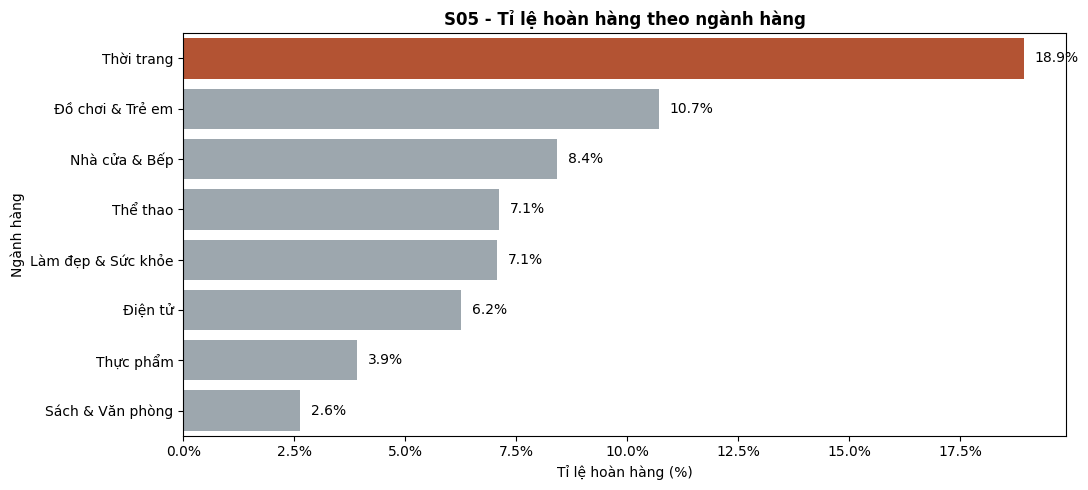

Kết luận S05: Thời trang có tỉ lệ hoàn hàng 18.9%, cao nhất toàn sàn và khoảng 7.2 lần Sách & Văn phòng (2.6%). Đây là ngành cần ưu tiên giảm sai size/sai kỳ vọng và kiểm soát chi phí hoàn hàng.


In [22]:
# S05: Category return rate
s05_stats = (
    df.groupby('category')
      .agg(
          orders=('order_id', 'count'),
          revenue=('net_value', 'sum'),
          return_rate=('returned', 'mean'),
          profit=('profit', 'sum')
      )
      .sort_values('return_rate', ascending=False)
)
s05_stats['margin'] = s05_stats['profit'] / s05_stats['revenue']

display(
    s05_stats.assign(
        return_rate_pct=s05_stats['return_rate'] * 100,
        revenue_billion=s05_stats['revenue'] / 1_000_000_000,
        margin_pct=s05_stats['margin'] * 100,
    )
)

highlight_category = s05_stats.index[0]
colors = ['#C8491E' if cat == highlight_category else '#9AA7B1' for cat in s05_stats.index]

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=s05_stats['return_rate'] * 100, y=s05_stats.index, palette=colors, hue=s05_stats.index, legend=False)
ax.set_title('S05 - Tỉ lệ hoàn hàng theo ngành hàng', fontweight='bold')
ax.set_xlabel('Tỉ lệ hoàn hàng (%)')
ax.set_ylabel('Ngành hàng')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
for i, value in enumerate(s05_stats['return_rate'] * 100):
    ax.text(value + 0.25, i, f'{value:.1f}%', va='center')
plt.tight_layout()
plt.show()

fashion_rate = s05_stats.loc['Thời trang', 'return_rate']
books_rate = s05_stats.loc['Sách & Văn phòng', 'return_rate']
print(
    f"Kết luận S05: Thời trang có tỉ lệ hoàn hàng {fashion_rate:.1%}, cao nhất toàn sàn "
    f"và khoảng {fashion_rate/books_rate:.1f} lần Sách & Văn phòng ({books_rate:.1%}). "
    "Đây là ngành cần ưu tiên giảm sai size/sai kỳ vọng và kiểm soát chi phí hoàn hàng."
)


## S06 - Giao hàng trễ làm rating giảm rõ rệt

Code nhóm theo `delivery_days`, vẽ đường rating và đánh dấu ngưỡng giao hàng từ 4 ngày trở lên.


,delivery_days,orders,avg_rating,return_rate,return_rate_pct
0,1,842,4.408551,0.084323,8.432304
1,2,4445,4.377278,0.090664,9.066367
2,3,1866,4.124866,0.104502,10.450161
3,4,648,4.179012,0.091049,9.104938
4,5,127,3.716535,0.102362,10.236220
5,6,69,3.724638,0.086957,8.695652
6,7,3,2.333333,0.666667,66.666667


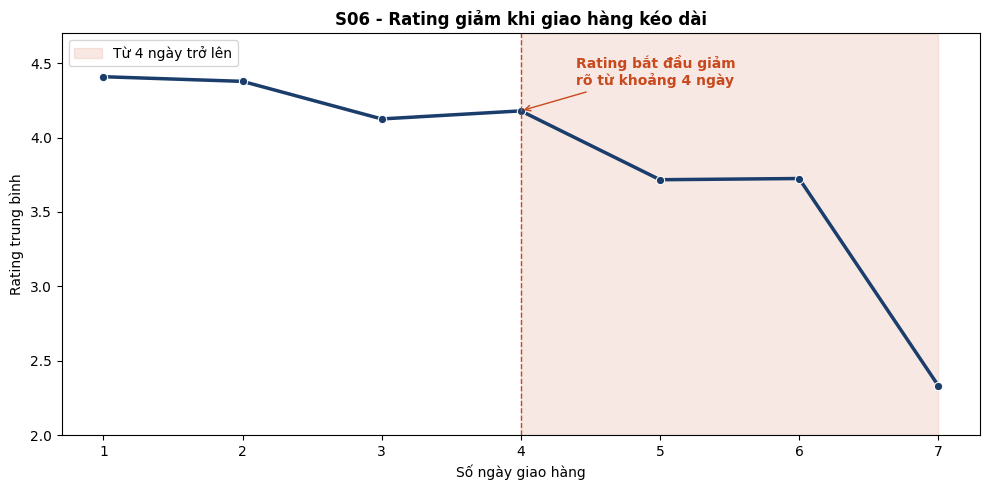

Kết luận S06: Đơn giao trong <=3 ngày có rating TB 4.32, trong khi nhóm >=4 ngày còn 4.07 và nhóm >=5 ngày còn 3.70. SLA nên ưu tiên giữ mốc tối đa 3 ngày để bảo vệ trải nghiệm khách hàng.


In [14]:
# S06: Delivery days vs rating
s06_stats = (
    df.groupby('delivery_days')
      .agg(
          orders=('order_id', 'count'),
          avg_rating=('rating', 'mean'),
          return_rate=('returned', 'mean')
      )
      .reset_index()
)

display(s06_stats.assign(return_rate_pct=s06_stats['return_rate'] * 100))

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=s06_stats, x='delivery_days', y='avg_rating', marker='o', linewidth=2.5, color='#1A3D6B')
ax.axvspan(4, s06_stats['delivery_days'].max(), color='#C8491E', alpha=0.12, label='Từ 4 ngày trở lên')
ax.axvline(4, color='#C8491E', linestyle='--', linewidth=1)
ax.annotate(
    'Rating bắt đầu giảm\nrõ từ khoảng 4 ngày',
    xy=(4, s06_stats.loc[s06_stats['delivery_days'] == 4, 'avg_rating'].iloc[0]),
    xytext=(4.4, 4.35),
    arrowprops=dict(arrowstyle='->', color='#C8491E'),
    color='#C8491E',
    fontweight='bold'
)
ax.set_title('S06 - Rating giảm khi giao hàng kéo dài', fontweight='bold')
ax.set_xlabel('Số ngày giao hàng')
ax.set_ylabel('Rating trung bình')
ax.set_ylim(2.0, 4.7)
ax.legend()
plt.tight_layout()
plt.show()

on_time_rating = df.loc[df['delivery_days'] <= 3, 'rating'].mean()
late_rating = df.loc[df['delivery_days'] >= 4, 'rating'].mean()
very_late_rating = df.loc[df['delivery_days'] >= 5, 'rating'].mean()
print(
    f"Kết luận S06: Đơn giao trong <=3 ngày có rating TB {on_time_rating:.2f}, "
    f"trong khi nhóm >=4 ngày còn {late_rating:.2f} và nhóm >=5 ngày còn {very_late_rating:.2f}. "
    "SLA nên ưu tiên giữ mốc tối đa 3 ngày để bảo vệ trải nghiệm khách hàng."
)


## S07 - App tạo phần lớn đơn hàng, nhưng Web có AOV cao hơn

Code nhóm theo `channel`, so sánh số đơn, tỉ trọng đơn và giá trị đơn hàng trung bình.


,orders,avg_order,revenue,profit,order_share,order_share_pct,avg_order_million,revenue_billion
channel,,,,,,,,
App,5989,9.707963e+05,5814098872,990541509,0.748625,74.8625,0.970796,5.814099
Web,1447,1.055323e+06,1527053015,229086813,0.180875,18.0875,1.055323,1.527053
Zalo Shop,304,9.766439e+05,296899751,51364769,0.038000,3.8000,0.976644,0.296900
Shopee Link,180,6.843270e+05,123178865,24644543,0.022500,2.2500,0.684327,0.123179
Facebook,80,7.761127e+05,62089012,10873799,0.010000,1.0000,0.776113,0.062089


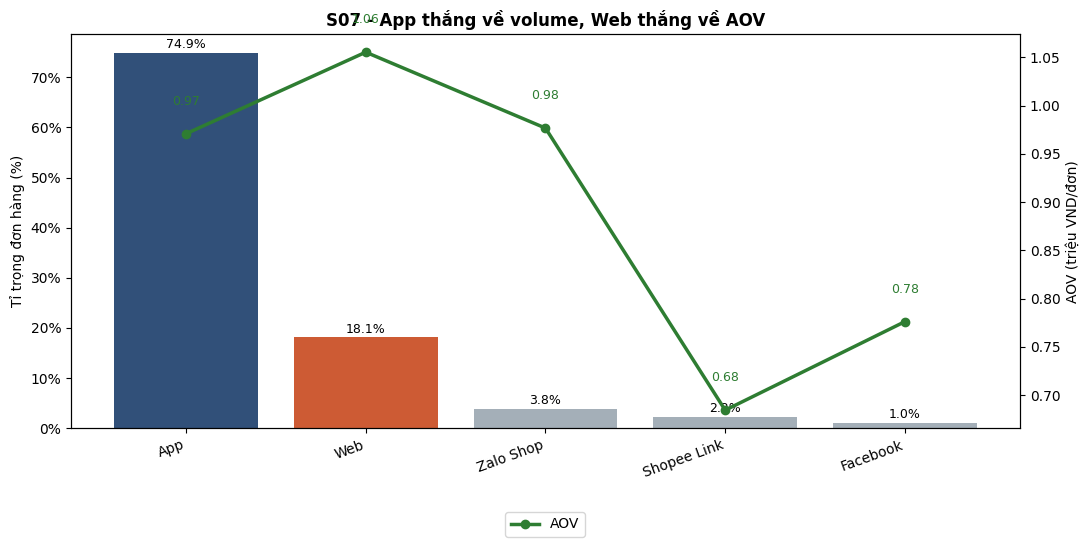

Kết luận S07: App chiếm 74.9% tổng số đơn, nhưng AOV Web đạt 1,055,323 VND so với App 970,796 VND, cao hơn 8.7%. App nên tối ưu chuyển đổi, Web nên được dùng cho giỏ hàng giá trị cao.


In [23]:
# S07: Channel order volume vs average order value
s07_stats = (
    df.groupby('channel')
      .agg(
          orders=('order_id', 'count'),
          avg_order=('net_value', 'mean'),
          revenue=('net_value', 'sum'),
          profit=('profit', 'sum')
      )
      .sort_values('orders', ascending=False)
)
s07_stats['order_share'] = s07_stats['orders'] / s07_stats['orders'].sum()

display(
    s07_stats.assign(
        order_share_pct=s07_stats['order_share'] * 100,
        avg_order_million=s07_stats['avg_order'] / 1_000_000,
        revenue_billion=s07_stats['revenue'] / 1_000_000_000,
    )
)

fig, ax1 = plt.subplots(figsize=(11, 5))
x = np.arange(len(s07_stats))
colors = ['#1A3D6B' if channel == 'App' else '#C8491E' if channel == 'Web' else '#9AA7B1' for channel in s07_stats.index]

ax1.bar(x, s07_stats['order_share'] * 100, color=colors, alpha=0.9)
ax1.set_ylabel('Tỉ trọng đơn hàng (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(s07_stats.index, rotation=20, ha='right')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax2 = ax1.twinx()
ax2.plot(x, s07_stats['avg_order'] / 1_000_000, color='#2E7D32', marker='o', linewidth=2.5, label='AOV')
ax2.set_ylabel('AOV (triệu VND/đơn)')

for i, row in enumerate(s07_stats.itertuples()):
    ax1.text(i, row.order_share * 100 + 1, f'{row.order_share*100:.1f}%', ha='center', fontsize=9)
    ax2.text(i, row.avg_order / 1_000_000 + 0.03, f'{row.avg_order/1_000_000:.2f}', ha='center', fontsize=9, color='#2E7D32')

ax1.set_title('S07 - App thắng về volume, Web thắng về AOV', fontweight='bold')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=1)
plt.tight_layout()
plt.show()

app = s07_stats.loc['App']
web = s07_stats.loc['Web']
web_premium = web['avg_order'] / app['avg_order'] - 1
print(
    f"Kết luận S07: App chiếm {app['order_share']:.1%} tổng số đơn, "
    f"nhưng AOV Web đạt {web['avg_order']:,.0f} VND so với App {app['avg_order']:,.0f} VND, "
    f"cao hơn {web_premium:.1%}. App nên tối ưu chuyển đổi, Web nên được dùng cho giỏ hàng giá trị cao."
)


## S08 - Nhóm Nam 45-54 có giá trị đơn hàng cao nhất nhưng quy mô nhỏ

Code tạo heatmap `age_group x gender` theo AOV, kèm bảng số đơn để xem nhóm giá trị cao có đang bị bỏ qua không.


,age_group,gender,avg_spend,orders,revenue,order_share,avg_spend_million,order_share_pct,revenue_billion
6,45-54,Nam,1.077546e+06,467,503214130,0.058375,1.077546,5.8375,0.503214
2,25-34,Nam,1.053751e+06,1586,1671248699,0.198250,1.053751,19.8250,1.671249
9,55+,Nữ,1.028973e+06,200,205794627,0.025000,1.028973,2.5000,0.205795
8,55+,Nam,1.025522e+06,200,205104353,0.025000,1.025522,2.5000,0.205104
0,18-24,Nam,1.018022e+06,806,820525407,0.100750,1.018022,10.0750,0.820525
4,35-44,Nam,1.008195e+06,986,994080500,0.123250,1.008195,12.3250,0.994081
3,25-34,Nữ,9.669684e+05,1493,1443683813,0.186625,0.966968,18.6625,1.443684
1,18-24,Nữ,9.104340e+05,784,713780284,0.098000,0.910434,9.8000,0.713780
5,35-44,Nữ,8.656317e+05,991,857841004,0.123875,0.865632,12.3875,0.857841
7,45-54,Nữ,8.378782e+05,487,408046698,0.060875,0.837878,6.0875,0.408047


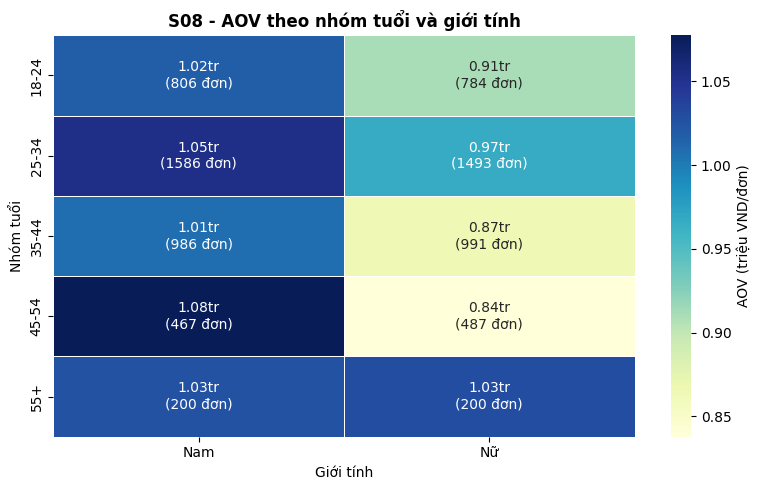

Kết luận S08: Nhóm Nam 45-54 có AOV cao nhất (1,077,546 VND/đơn) nhưng chỉ chiếm 5.8% số đơn. Đây là phân khúc nên được thử nghiệm targeting riêng vì giá trị đơn hàng cao nhưng volume còn nhỏ.


In [16]:
# S08: Age group and gender heatmap
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
gender_order = ['Nam', 'Nữ']

s08_stats = (
    df.groupby(['age_group', 'gender'])
      .agg(
          avg_spend=('net_value', 'mean'),
          orders=('order_id', 'count'),
          revenue=('net_value', 'sum')
      )
      .reset_index()
)
s08_stats['order_share'] = s08_stats['orders'] / len(df)

avg_spend_matrix = (
    s08_stats.pivot(index='age_group', columns='gender', values='avg_spend')
             .reindex(index=age_order, columns=gender_order)
)
orders_matrix = (
    s08_stats.pivot(index='age_group', columns='gender', values='orders')
             .reindex(index=age_order, columns=gender_order)
)

annot = avg_spend_matrix.copy().astype(str)
for age in avg_spend_matrix.index:
    for gender in avg_spend_matrix.columns:
        annot.loc[age, gender] = f"{avg_spend_matrix.loc[age, gender]/1_000_000:.2f}tr\n({int(orders_matrix.loc[age, gender])} đơn)"

display(
    s08_stats.sort_values('avg_spend', ascending=False).assign(
        avg_spend_million=s08_stats['avg_spend'] / 1_000_000,
        order_share_pct=s08_stats['order_share'] * 100,
        revenue_billion=s08_stats['revenue'] / 1_000_000_000,
    )
)

plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    avg_spend_matrix / 1_000_000,
    annot=annot,
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'AOV (triệu VND/đơn)'}
)
ax.set_title('S08 - AOV theo nhóm tuổi và giới tính', fontweight='bold')
ax.set_xlabel('Giới tính')
ax.set_ylabel('Nhóm tuổi')
plt.tight_layout()
plt.show()

top_segment = s08_stats.sort_values('avg_spend', ascending=False).iloc[0]
print(
    f"Kết luận S08: Nhóm {top_segment['gender']} {top_segment['age_group']} có AOV cao nhất "
    f"({top_segment['avg_spend']:,.0f} VND/đơn) nhưng chỉ chiếm {top_segment['order_share']:.1%} số đơn. "
    "Đây là phân khúc nên được thử nghiệm targeting riêng vì giá trị đơn hàng cao nhưng volume còn nhỏ."
)
